In [2]:
import numpy as np 
import pandas as pd

In [16]:
df= pd.read_csv("datos/train.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [4]:
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [17]:
cat=df.select_dtypes(include=['str']).columns
num=df.select_dtypes(include=['int64','float64']).columns
print("==============Categoricas==========================")
print(cat)
print("===============Numericas=========================")
print(num)

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='str')
Index(['id', 'Age', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work'],
      dtype='str')


In [19]:
cat=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']
num=['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [ ]:
X = df.drop(columns=['id', 'Will_Buy_EV'])
for c in cat:
    X[c] = X[c].astype('category')
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [24]:
negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.725913318989971


In [23]:
print("Distribución completa:")
print(y.value_counts())

print("\nProporción:")
print(y.value_counts(normalize=True))
print("=========================")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

Distribución completa:
Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64

Proporción:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64
Train:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64

Validation:
Will_Buy_EV
0    0.825354
1    0.174646
Name: proportion, dtype: float64


In [25]:


categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
preprocessor = ColumnTransformer(transformers=[
   
    ("cat", categorical_transformer, cat),
])

In [28]:


model = XGBClassifier(
    n_estimators=3000,          
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    tree_method='hist',        
    enable_categorical=True,
    eval_metric='auc',
    early_stopping_rounds=100,
    n_jobs=-1,
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=200)

proba = model.predict_proba(X_val)[:, 1]
print("AUC:", roc_auc_score(y_val, proba))
print("Mejor iteración:", model.best_iteration)

[0]	validation_0-auc:0.93672
[200]	validation_0-auc:0.94111
[400]	validation_0-auc:0.94165
[597]	validation_0-auc:0.94166
AUC: 0.941693075686081
Mejor iteración: 497


In [30]:
umbrales = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_val, proba >= u) for u in umbrales]
mejor_u = umbrales[np.argmax(f1s)]
print("Mejor umbral:", mejor_u, "F1:", max(f1s))
print(classification_report(y_val, proba >= mejor_u))

Mejor umbral: 0.3599999999999999 F1: 0.71624674196351
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    110377
           1       0.65      0.79      0.72     23356

    accuracy                           0.89    133733
   macro avg       0.80      0.85      0.82    133733
weighted avg       0.90      0.89      0.89    133733



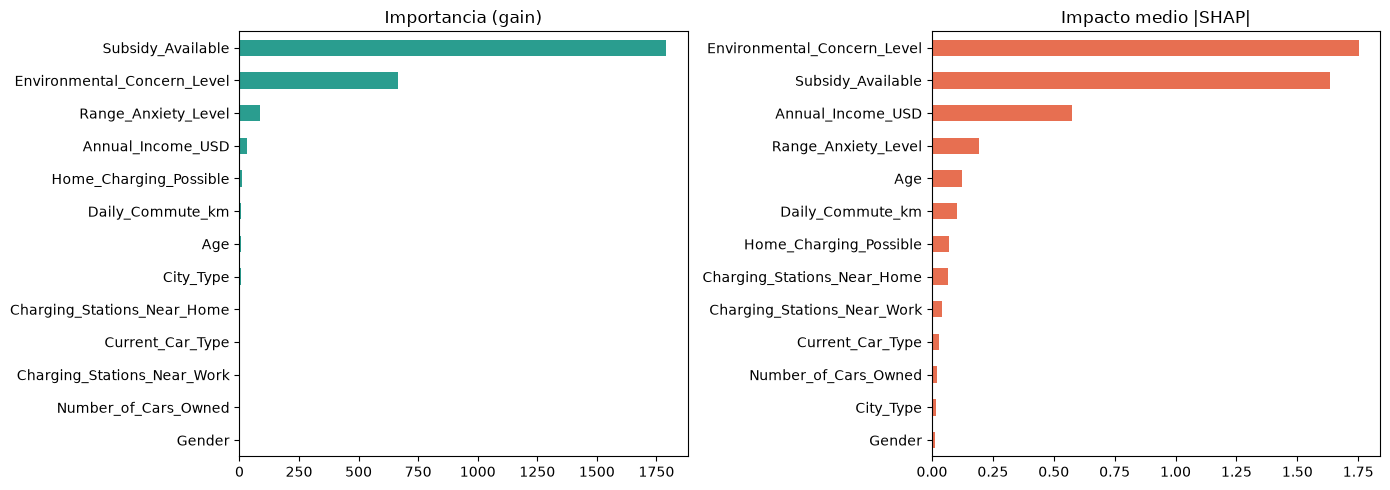

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt
import xgboost as xgb

gain = pd.Series(model.get_booster().get_score(importance_type='gain')).sort_values()

muestra = X_val.sample(20000, random_state=42)
dm = xgb.DMatrix(muestra, enable_categorical=True)
contrib = model.get_booster().predict(dm, pred_contribs=True)[:, :-1]  # la última columna es el sesgo
shap_imp = pd.Series(np.abs(contrib).mean(axis=0), index=muestra.columns).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
gain.plot.barh(ax=ax[0], color='#2a9d8f', title='Importancia (gain)')
shap_imp.plot.barh(ax=ax[1], color='#e76f51', title='Impacto medio |SHAP|')
plt.tight_layout()
plt.show()
import os
os.makedirs("imagenes", exist_ok=True)
plt.savefig("imagenes/importancia_variables.png", dpi=150, bbox_inches="tight")

In [33]:
import json

model.save_model("modelo/modelo_xgb.json")

config = {
    "umbral": float(mejor_u),
    "categorias": {c: list(X_train[c].cat.categories) for c in cat},
    "columnas": list(X_train.columns),
}
with open("modelo/config_modelo.json", "w") as f:
    json.dump(config, f, indent=2)

In [5]:
import json

df_test = pd.read_csv("datos/test.csv")

modelo = XGBClassifier()
modelo.load_model("modelo/modelo_xgb.json")
with open("modelo/config_modelo.json") as f:
    config = json.load(f)

X_test = df_test[config["columnas"]].copy()
for c, cats in config["categorias"].items():
    X_test[c] = pd.Categorical(X_test[c], categories=cats)

proba_test = modelo.predict_proba(X_test)[:, 1]

resultado = pd.DataFrame({
    "id": df_test["id"],
    "Will_Buy_EV": proba_test,   
})
resultado.to_csv("predicciones/predicciones_XGBOOST.csv", index=False)
print(resultado["Will_Buy_EV"].value_counts(normalize=True))

Will_Buy_EV
0.000897    0.000010
0.005901    0.000010
0.009156    0.000010
0.879157    0.000010
0.000363    0.000010
              ...   
0.000204    0.000003
0.249883    0.000003
0.002644    0.000003
0.000429    0.000003
0.000112    0.000003
Name: proportion, Length: 284945, dtype: float64
